### Tutorial Notebook for Structure Initialization and Loss Function Application
In this notebook, we provide examples of generating a few common crystal structures, and use these generated structures to test out the loss functions.

In [4]:
import numpy as onp

from jax import config
config.update('jax_enable_x64', True)

import jax.numpy as jnp
from jax import vmap, jit
from jax import scipy

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.collections import EllipseCollection

In [5]:
def make_2D_lattice_from_index_list(index_list,
                                    a0=jnp.array([jnp.sqrt(2),0.0]),
                                    a1=jnp.array([0.0,jnp.sqrt(2)]),
                                    unitcell=jnp.array([[0.0, 0.0]]),
                                    offset=jnp.array([0.0,0.0])):
  unitcell_particles = unitcell + offset 
  N = len(unitcell_particles)*index_list.shape[0]
  def get_cell(i,j):
    cell_shift = i*a0+j*a1
    return unitcell_particles + cell_shift

  return jnp.reshape(vmap(get_cell, in_axes=(0, 0))(index_list[:,0],index_list[:,1]),(N,2))

def make_2D_lattice(irange, jrange, **kwargs):
  index_list = jnp.array([ [i,j] for i in irange for j in jrange])
  return make_2D_lattice_from_index_list(index_list, **kwargs)

make_2D_lattice = jit(make_2D_lattice)

def make_3D_lattice_from_index_list(index_list,
                                    a0=jnp.array([jnp.sqrt(2),0.0,0.0]),
                                    a1=jnp.array([0.0,jnp.sqrt(2),0.0]),
                                    a2=jnp.array([0.0,0.0,jnp.sqrt(2)]),
                                    unitcell=jnp.array([[0.0, 0.0, 0.0]]),
                                    offset=jnp.array([0.0,0.0,0.0])):
  unitcell_particles = unitcell + offset
  N = len(unitcell_particles)*index_list.shape[0]
  def get_cell(i,j,k):
    cell_shift = i*a0+j*a1+k*a2
    return unitcell_particles + cell_shift

  return jnp.reshape(vmap(get_cell, in_axes=(0,0,0))(index_list[:,0],index_list[:,1],index_list[:,2]),(N,3))

def make_3D_lattice(irange, jrange, krange, **kwargs):
  index_list = jnp.array([ [i,j,k] for i in irange for j in jrange for k in krange])
  return make_3D_lattice_from_index_list(index_list, **kwargs)

make_3D_lattice = jit(make_3D_lattice)

#### 2D Structure Generation

In [6]:
### Global Parameters
M = 20
A = 1.2
BOX_SIZE = 15

### Square Lattice
A0_sq = jnp.array([A, 0])
A1_sq = jnp.array([0, A])
UNITCELL_sq = jnp.array([[0.0,0.0]])

### Triangular Lattice
A0_tri = jnp.array([A, 0])
A1_tri = jnp.array([A/2, jnp.sqrt(3)*A/2])
UNITCELL_tri = jnp.array([[0.0,0.0]])

### Kagome Lattice
A0_kag = jnp.array([A*2.0, 0])
A1_kag = jnp.array([A, jnp.sqrt(3)*A])
UNITCELL_kag = jnp.array([[0.0,0.0],
                      [A, 0.0],
                      [A/2, jnp.sqrt(3)*A/2]])

### Honeycomb Lattice
A0_hon = jnp.array([A*3.0/2, jnp.sqrt(3)*A/2])
A1_hon = jnp.array([A*3.0/2, -jnp.sqrt(3)*A/2])
UNITCELL_hon = jnp.array([[-A/2.0, jnp.sqrt(3)*A/2],
                      [A/2.0, jnp.sqrt(3)*A/2]])


In [7]:
R_sq = (make_2D_lattice)(jnp.arange(0,M),jnp.arange(0,M),
                      a0 = A0_sq,
                      a1 = A1_sq,
                      unitcell= UNITCELL_sq,
                      offset=jnp.array([0.01, 0.03]))
R_sq = R_sq - jnp.average(R_sq, axis = 0) + jnp.array([BOX_SIZE/2, BOX_SIZE/2])

R_tri = (make_2D_lattice)(jnp.arange(0,M),jnp.arange(0,M),
                      a0 = A0_tri,
                      a1 = A1_tri,
                      unitcell= UNITCELL_tri,
                      offset=jnp.array([0.01, 0.03]))
R_tri = R_tri - jnp.average(R_tri, axis = 0) + jnp.array([BOX_SIZE/2, BOX_SIZE/2])

R_kag = (make_2D_lattice)(jnp.arange(0,M),jnp.arange(0,M),
                      a0 = A0_kag,
                      a1 = A1_kag,
                      unitcell= UNITCELL_kag,
                      offset=jnp.array([0.01, 0.03]))
R_kag = R_kag - jnp.average(R_kag, axis = 0) + jnp.array([BOX_SIZE/2, BOX_SIZE/2])

R_hon = (make_2D_lattice)(jnp.arange(0,M),jnp.arange(0,M),
                      a0 = A0_hon,
                      a1 = A1_hon,
                      unitcell= UNITCELL_hon,
                      offset=jnp.array([0.01, 0.03]))
R_hon = R_hon - jnp.average(R_hon, axis = 0) + jnp.array([BOX_SIZE/2, BOX_SIZE/2])


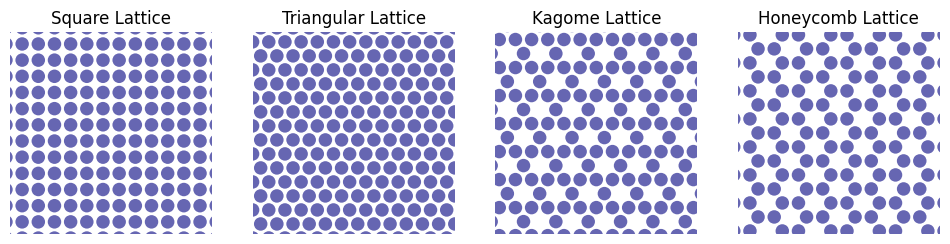

In [8]:
fig, axs = plt.subplots(1, 4)
fig.set_size_inches(12, 3)
axs[0].add_collection(EllipseCollection(widths=1.0, heights=1.0, angles=0, units='xy',
                                       facecolors='navy', alpha = 0.6, 
                                       offsets=list(R_sq), transOffset=axs[0].transData))
axs[0].set_xlim([0, BOX_SIZE])
axs[0].set_ylim([0, BOX_SIZE])
axs[0].set_aspect('equal', 'box')
axs[0].set_axis_off()
axs[0].set_title("Square Lattice")

axs[1].add_collection(EllipseCollection(widths=1.0, heights=1.0, angles=0, units='xy',
                                       facecolors='navy', alpha = 0.6, 
                                       offsets=list(R_tri), transOffset=axs[1].transData))
axs[1].set_xlim([0, BOX_SIZE])
axs[1].set_ylim([0, BOX_SIZE])
axs[1].set_aspect('equal', 'box')
axs[1].set_axis_off()
axs[1].set_title("Triangular Lattice")

axs[2].add_collection(EllipseCollection(widths=1.0, heights=1.0, angles=0, units='xy',
                                       facecolors='navy', alpha = 0.6, 
                                       offsets=list(R_kag), transOffset=axs[2].transData))
axs[2].set_xlim([0, BOX_SIZE])
axs[2].set_ylim([0, BOX_SIZE])
axs[2].set_aspect('equal', 'box')
axs[2].set_axis_off()
axs[2].set_title("Kagome Lattice")

axs[3].add_collection(EllipseCollection(widths=1.0, heights=1.0, angles=0, units='xy',
                                       facecolors='navy', alpha = 0.6, 
                                       offsets=list(R_hon), transOffset=axs[3].transData))
axs[3].set_xlim([0, BOX_SIZE])
axs[3].set_ylim([0, BOX_SIZE])
axs[3].set_aspect('equal', 'box')
axs[3].set_axis_off()
axs[3].set_title("Honeycomb Lattice")

#### 3D Structure Generation

In [9]:
### Global Parameters
M = 5
A = 1.2
BOX_SIZE = 10

### Simple Cubic Structure
A0_sc = jnp.array([A, 0, 0])
A1_sc = jnp.array([0, A, 0])
A2_sc = jnp.array([0, 0, A])
UNITCELL_sc = jnp.array([[0.0, 0.0, 0.0]])

### Face Centered Cubic Structure
A0_fcc = jnp.array([0, A/2, A/2])
A1_fcc = jnp.array([A/2, 0, A/2])
A2_fcc = jnp.array([A/2, A/2, 0])
UNITCELL_fcc = jnp.array([[0.0, 0.0, 0.0]])

### Body Centered Cubic Structure
A0_bcc = jnp.array([-A/2, A/2, A/2])
A1_bcc = jnp.array([A/2, -A/2, A/2])
A2_bcc = jnp.array([A/2, A/2, -A/2])
UNITCELL_bcc = jnp.array([[0.0, 0.0, 0.0]])

### Diamond Structure
A0_dia = jnp.array([0, A/2, A/2])
A1_dia = jnp.array([A/2, 0, A/2])
A2_dia = jnp.array([A/2, A/2, 0])
UNITCELL_dia = jnp.array([[0, 0, 0],
                          [A/4, A/4, A/4]])

In [10]:
R_sc = (make_3D_lattice)(jnp.arange(0,M),jnp.arange(0,M),jnp.arange(0,M),
                      a0 = A0_sc,
                      a1 = A1_sc,
                      a2 = A2_sc,
                      unitcell= UNITCELL_sc,
                      offset=jnp.array([0.01, 0.02, 0.03]))
R_sc = R_sc - jnp.average(R_sc, axis = 0) + jnp.array([BOX_SIZE/2, BOX_SIZE/2, BOX_SIZE/2])

R_fcc = (make_3D_lattice)(jnp.arange(0,M),jnp.arange(0,M),jnp.arange(0,M),
                      a0 = A0_fcc,
                      a1 = A1_fcc,
                      a2 = A2_fcc,
                      unitcell= UNITCELL_fcc,
                      offset=jnp.array([0.01, 0.02, 0.03]))
R_fcc = R_fcc - jnp.average(R_fcc, axis = 0) + jnp.array([BOX_SIZE/2, BOX_SIZE/2, BOX_SIZE/2])

R_bcc = (make_3D_lattice)(jnp.arange(0,M),jnp.arange(0,M),jnp.arange(0,M),
                      a0 = A0_bcc,
                      a1 = A1_bcc,
                      a2 = A2_bcc,
                      unitcell= UNITCELL_fcc,
                      offset=jnp.array([0.01, 0.02, 0.03]))
R_bcc = R_bcc - jnp.average(R_bcc, axis = 0) + jnp.array([BOX_SIZE/2, BOX_SIZE/2, BOX_SIZE/2])

R_dia = (make_3D_lattice)(jnp.arange(0,M),jnp.arange(0,M),jnp.arange(0,M),
                      a0 = A0_dia,
                      a1 = A1_dia,
                      a2 = A2_dia,
                      unitcell= UNITCELL_dia,
                      offset=jnp.array([0.01, 0.02, 0.03]))
R_dia = R_dia - jnp.average(R_dia, axis = 0) + jnp.array([BOX_SIZE/2, BOX_SIZE/2, BOX_SIZE/2])

Text(0.5, 1.0, 'Diamond Structure')

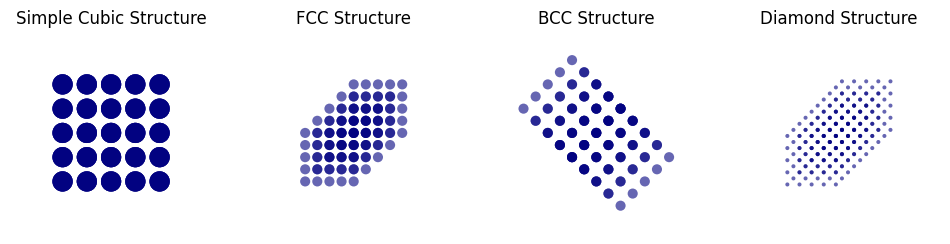

In [11]:
fig, axs = plt.subplots(1, 4)
fig.set_size_inches(12, 3)
axs[0].add_collection(EllipseCollection(widths=1.0, heights=1.0, angles=0, units='xy',
                                       facecolors='navy', alpha = 0.6, 
                                       offsets=list(R_sc[:,:2]), transOffset=axs[0].transData))
axs[0].set_xlim([0, BOX_SIZE])
axs[0].set_ylim([0, BOX_SIZE])
axs[0].set_aspect('equal', 'box')
axs[0].set_axis_off()
axs[0].set_title("Simple Cubic Structure")

axs[1].add_collection(EllipseCollection(widths=0.5, heights=0.5, angles=0, units='xy',
                                       facecolors='navy', alpha = 0.6, 
                                       offsets=list(R_fcc[:,:2]), transOffset=axs[1].transData))
axs[1].set_xlim([0, BOX_SIZE])
axs[1].set_ylim([0, BOX_SIZE])
axs[1].set_aspect('equal', 'box')
axs[1].set_axis_off()
axs[1].set_title("FCC Structure")

axs[2].add_collection(EllipseCollection(widths=0.5, heights=0.5, angles=0, units='xy',
                                       facecolors='navy', alpha = 0.6, 
                                       offsets=list(R_bcc[:,:2]), transOffset=axs[2].transData))
axs[2].set_xlim([0, BOX_SIZE])
axs[2].set_ylim([0, BOX_SIZE])
axs[2].set_aspect('equal', 'box')
axs[2].set_axis_off()
axs[2].set_title("BCC Structure")

axs[3].add_collection(EllipseCollection(widths=0.2, heights=0.2, angles=0, units='xy',
                                       facecolors='navy', alpha = 0.6, 
                                       offsets=list(R_dia[:,1:]), transOffset=axs[3].transData))
axs[3].set_xlim([0, BOX_SIZE])
axs[3].set_ylim([0, BOX_SIZE])
axs[3].set_aspect('equal', 'box')
axs[3].set_axis_off()
axs[3].set_title("Diamond Structure")

#### Loss Functions

In [12]:
def get_psi_k(displacement_all, k=6, r0=1.1, alpha=100):

  def weight(r):
    return jnp.where(r<1e-7, 0., 1.0/(1 + jnp.exp(alpha*(r - r0))))

  i_imaginary = complex(0,1)
  def get_ylms(dR_ij):
    epsilon = 0.00001 #avoids nan in derivative
    dR_ij = jnp.where(dR_ij==0.0, epsilon, dR_ij)
    theta = jnp.arctan2(dR_ij[1], dR_ij[0])
    return jnp.exp(i_imaginary*k*theta)

  def calculate_order_param(R):
    v_get_ylms = vmap(vmap(get_ylms))
    ds = displacement_all(R, R)
    r = space.distance(ds)
    w = weight(r)
    psi_k = (jnp.sum(v_get_ylms(ds)*w, axis=0)/(jnp.sum(w, axis=0)+0.00001))
    return psi_k

  def average_order_param(R):
    psi_k = calculate_order_param(R)
    return jnp.abs(jnp.mean(psi_k))

  return average_order_param

In [13]:
def get_Q_l(displacement_all, l = 6, r0 = 1.1, alpha = 100):

  def Ylm(theta, phi):
    m = jnp.arange(-l, l + 1)
    return scipy.special.sph_harm_y(jnp.array([l]), m, 
                                    jnp.array([theta]), jnp.array([phi]))

  def get_ylms(dR_ij):
    epsilon = 0.00001 #avoids nan in derivative
    dR_ij = jnp.where(dR_ij==0.0, epsilon, dR_ij)
    phi = jnp.arctan2(dR_ij[1], dR_ij[0])
    rsin = jnp.sqrt(dR_ij[0]**2 + dR_ij[1]**2)
    theta = jnp.arctan2(rsin, dR_ij[2])
    return Ylm(theta, phi)

  def weight(r):
    return jnp.where(r<1e-7, 0., 1.0/(1 + jnp.exp(alpha*(r - r0))))

  def calculate_order_param(R):
    v_get_ylms = vmap(vmap(get_ylms))
    ds = displacement_all(R, R)
    r = space.distance(ds)
    w = jnp.expand_dims(weight(r), -1)
    q_lm = (jnp.sum(v_get_ylms(ds)*w, axis=0)/(jnp.sum(w, axis=0)+0.000001)).reshape(-1,1,l*2+1)
    q_lm_broad = jnp.repeat(q_lm, repeats=len(q_lm), axis=1)
    ave_q_lm = jnp.sum(q_lm_broad*w, axis=0)/(jnp.sum(w, axis=0)+0.000001)
    Qlm_each_particle = jnp.sqrt(4*jnp.pi*jnp.abs(jnp.einsum('...m, ...m', jnp.conj(ave_q_lm), ave_q_lm))/(l*2+1))
    return jnp.mean(Qlm_each_particle)

  return calculate_order_param

In [22]:
from jax_md import space

displacement, shift = space.periodic(BOX_SIZE*4)

displacement_all = vmap(vmap(displacement, (0, None), 0), (None, 0), 0)
order_param_2D = get_psi_k(displacement_all, k=6, r0=1.3, alpha=100)
order_param_3D = get_Q_l(displacement_all, l=6, r0=1.3, alpha=100)

print(order_param_2D(R_tri))
print(order_param_3D(R_fcc))

0.9999981578261953
0.3453546648685588
